In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score,roc_curve
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [4]:
data1 = pd.read_csv('heart.csv')

In [5]:
data1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
data1.shape

(1025, 14)

In [8]:
data1.index

RangeIndex(start=0, stop=1025, step=1)

In [9]:
data1.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [10]:
data1.isna()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1021,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1022,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1023,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
data1.isna().any()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [12]:
data1.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
data1.duplicated().any()

True

In [14]:
data2 = data1.drop_duplicates()

In [15]:
data1.shape, data2.shape

((1025, 14), (302, 14))

In [16]:
data2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<AxesSubplot:>

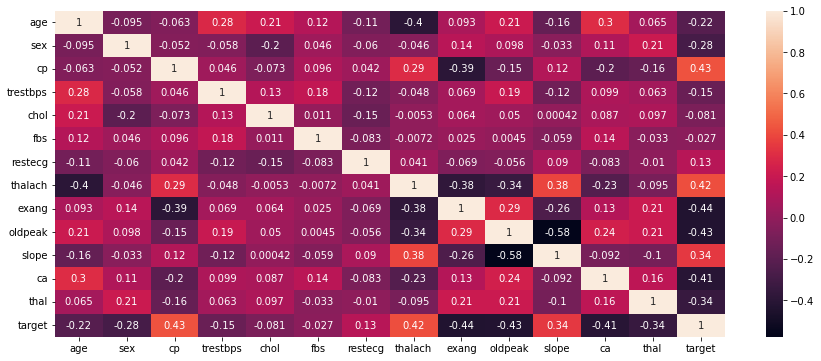

In [17]:
plt.figure(figsize=(15,6))
sns.heatmap(data2.corr(), annot=True)

In [18]:
data2

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [19]:
data2['target'].value_counts()

1    164
0    138
Name: target, dtype: int64

<AxesSubplot:xlabel='target', ylabel='count'>

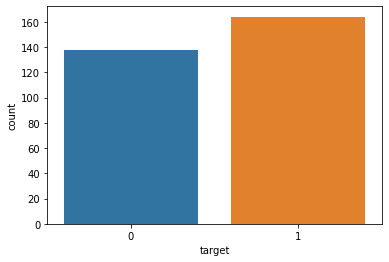

In [20]:
sns.countplot(x='target',data=data2)

In [21]:
data2['sex'].value_counts()

1    206
0     96
Name: sex, dtype: int64

<AxesSubplot:xlabel='sex', ylabel='count'>

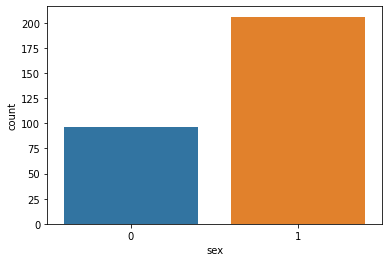

In [22]:
sns.countplot(x='sex', data=data2)

## Removing Outliers

<AxesSubplot:>

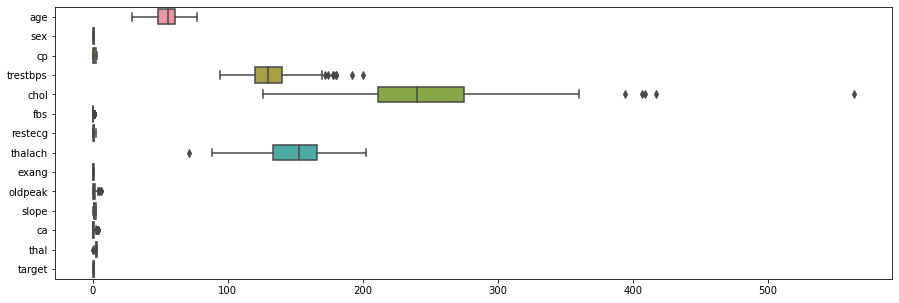

In [23]:
plt.figure(figsize=(15,5))
sns.boxplot(data=data2,orient='h')

In [24]:
data2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


outliers on right side in chol is 
 123    417
158    564
179    409
255    394
450    407
Name: chol, dtype: int64 



<AxesSubplot:xlabel='chol'>

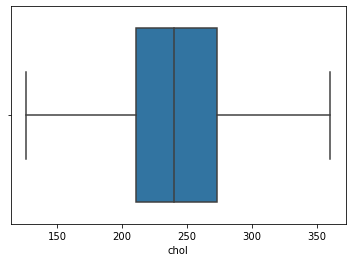

In [25]:
q1 = data2.chol.quantile(0.25)
q3 = data2.chol.quantile(0.75)
IQR = q3 - q1
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
k1=data2[data2["chol"]>upper_limit]
print("outliers on right side in chol is \n",k1["chol"],"\n")
data2=data2[data2["chol"]<upper_limit]
sns.boxplot(data2["chol"])

In [26]:
data2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.282828,0.693603,0.966330,131.531987,243.272727,0.148148,0.535354,149.468013,0.329966,1.028620,1.400673,0.710438,2.309764,0.542088
std,9.047966,0.461775,1.032681,17.638252,44.996731,0.355846,0.525944,23.078446,0.470994,1.156805,0.618739,1.001852,0.613755,0.499066
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.700000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,273.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,360.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<AxesSubplot:>

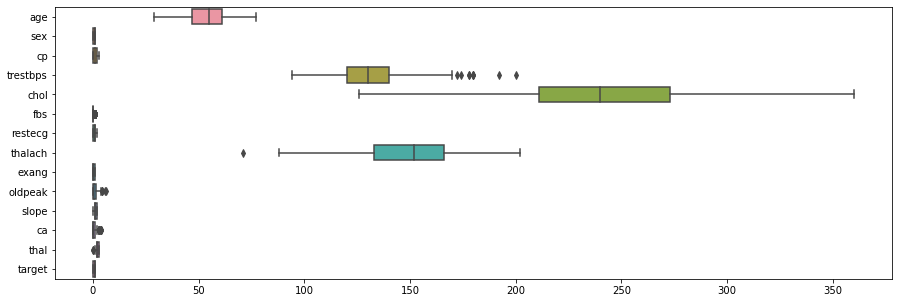

In [27]:
plt.figure(figsize=(15,5))
sns.boxplot(data=data2,orient='h')

<AxesSubplot:xlabel='trestbps'>

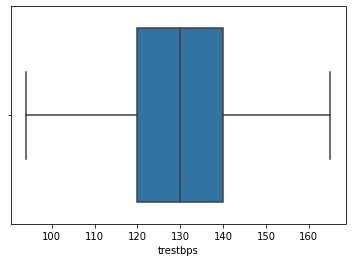

In [28]:
q1 = data2.trestbps.quantile(0.25)
q3 = data2.trestbps.quantile(0.75)
IQR = q3 - q1
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
k1=data2[data2["chol"] > upper_limit]
data2=data2[data2["trestbps"] < upper_limit]
sns.boxplot(data2["trestbps"])

<AxesSubplot:>

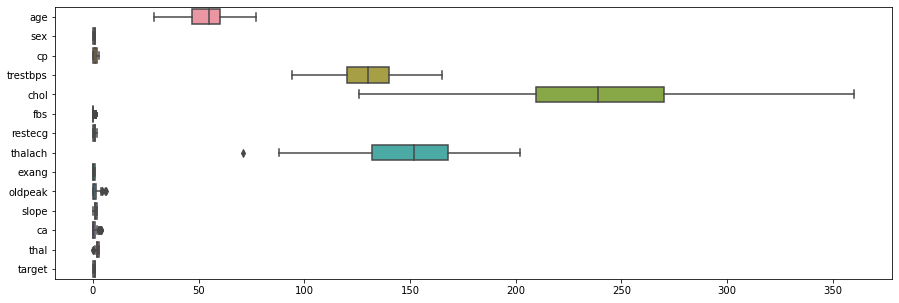

In [29]:
plt.figure(figsize=(15,5))
sns.boxplot(data=data2,orient='h')

<AxesSubplot:xlabel='thalach'>

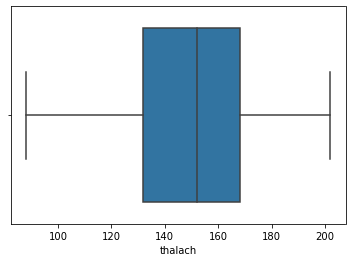

In [30]:
q1 = data2.thalach.quantile(0.25)
q3 = data2.thalach.quantile(0.75)
IQR = q3 - q1
lower_limit = q1 - 1.5 * IQR
k1=data2[data2["thalach"] < lower_limit]
data2=data2[data2["thalach"] > lower_limit]
sns.boxplot(data2["thalach"])

<AxesSubplot:>

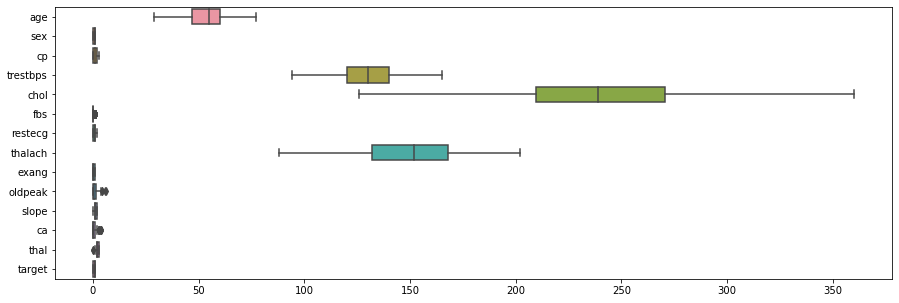

In [31]:
plt.figure(figsize=(15,5))
sns.boxplot(data=data2,orient='h')

In [32]:
data2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000
mean,54.000000,0.699647,0.964664,129.438163,242.070671,0.137809,0.537102,149.671378,0.318021,0.999293,1.420495,0.720848,2.296820,0.554770
std,9.113547,0.459224,1.020441,14.784944,44.890275,0.345310,0.520367,22.861163,0.466533,1.126628,0.610084,1.008733,0.610392,0.497872
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,88.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,209.500000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,239.000000,0.000000,1.000000,152.000000,0.000000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,270.500000,0.000000,1.000000,168.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,165.000000,360.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [33]:
data2.shape

(283, 14)

<AxesSubplot:>

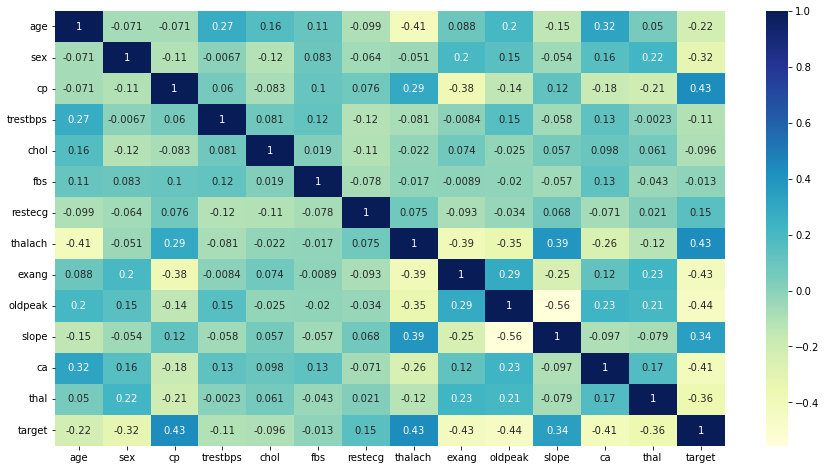

In [57]:
plt.figure(figsize = (15,8))
sns.heatmap(data2.corr(),annot=True,cmap='YlGnBu')

## Data Splitting & Standardization

In [35]:
data2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [36]:
x = data2.drop('target',axis=1)
y = data2['target']

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20,random_state=42)

In [38]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train

array([[ 0.33870449,  0.65603334, -0.96528661, ..., -0.66426877,
         0.30960709, -2.08571429],
       [-1.07883651,  0.65603334,  1.054665  , ...,  0.94997577,
        -0.67590279, -0.47142857],
       [-0.75171167,  0.65603334, -0.96528661, ..., -0.66426877,
         0.30960709, -0.47142857],
       ...,
       [ 0.33870449,  0.65603334, -0.96528661, ..., -0.66426877,
         0.30960709,  1.14285714],
       [ 0.77487095,  0.65603334, -0.96528661, ..., -0.66426877,
         0.30960709, -0.47142857],
       [-0.20650359,  0.65603334,  1.054665  , ...,  0.94997577,
         3.26613673, -0.47142857]])

In [39]:
x_test = scaler.transform(x_test)
x_test

array([[ 0.01157964,  0.65603334, -0.96528661, -0.49543023,  0.94573559,
        -0.40613847, -1.03635106, -1.48573827,  1.47753125,  2.07856377,
        -0.66426877,  1.29511697, -0.47142857],
       [-1.40596136,  0.65603334,  1.054665  ,  0.05242167, -0.63278626,
        -0.40613847, -1.03635106,  0.77714355, -0.67680464,  0.9664973 ,
        -0.66426877, -0.67590279, -0.47142857],
       [-1.40596136,  0.65603334,  1.054665  , -1.1802451 ,  0.15647467,
        -0.40613847,  0.93184507,  1.25583009, -0.67680464, -0.88694682,
         0.94997577, -0.67590279, -0.47142857],
       [ 0.66582933,  0.65603334, -0.96528661,  0.05242167, -0.80817758,
        -0.40613847, -1.03635106, -0.78946694,  1.47753125,  1.33718612,
        -0.66426877,  1.29511697,  1.14285714],
       [ 0.88391256, -1.52431277, -0.96528661, -0.35846725, -0.74240584,
        -0.40613847,  0.93184507,  0.55955876, -0.67680464, -0.88694682,
         0.94997577, -0.67590279, -0.47142857],
       [ 1.21103741,  0.656033

## Logistic Regression

In [40]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [41]:
lr_pred = lr.predict(x_test)
pd.DataFrame(np.c_[y_test,lr_pred],columns=['Actual','Predicted']).head()

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1


 Test Accuracy score :  85.96 %
Train Accuracy score :  84.07 %
----------------------
Classification Report
----------------------
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        25
           1       0.88      0.88      0.88        32

    accuracy                           0.86        57
   macro avg       0.86      0.86      0.86        57
weighted avg       0.86      0.86      0.86        57



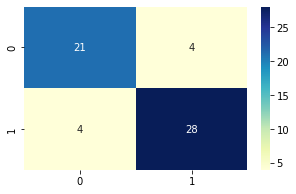

In [42]:
print(" Test Accuracy score : ",round(lr.score(x_test,y_test)*100,2),"%")
print("Train Accuracy score : ",round(lr.score(x_train,y_train)*100,2),"%")
print("----------------------")
print("Classification Report")
print("----------------------")
con = confusion_matrix(lr_pred,y_test)
plt.figure(figsize=(5,3))
sns.heatmap(con, annot=True,cmap="YlGnBu",fmt='g')
print(classification_report(y_test,lr_pred))

In [43]:
auc = roc_auc_score(y_test,lr_pred)
auc

0.8574999999999999

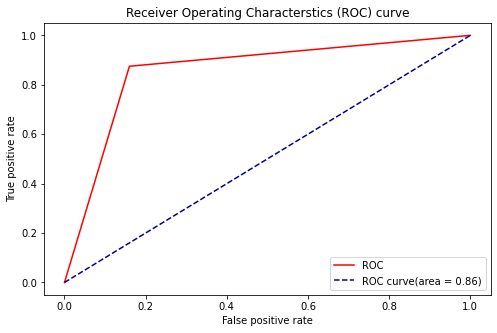

In [44]:
fpr, tpr, thresholds = roc_curve(y_test,lr_pred)
plt.figure(figsize=(8,5))
plt.plot(fpr , tpr , color='red',label='ROC')
plt.plot([0,1],[0,1],color = 'darkblue',linestyle='--',label='ROC curve(area = %0.2f)'% auc)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver Operating Characterstics (ROC) curve')
plt.legend()
plt.show()

# Random Forest

In [45]:
rfc = RandomForestClassifier(max_depth=2, random_state=0)
rfc.fit(x_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [46]:
rfc_pred = rfc.predict(x_test)
pd.DataFrame(np.c_[y_test,rfc_pred],columns=['Actual','Predicted']).head()

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1


 Test Accuracy score :  91.23 %
Train Accuracy score :  85.84 %
----------------------
Classification Report
----------------------
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        25
           1       0.91      0.94      0.92        32

    accuracy                           0.91        57
   macro avg       0.91      0.91      0.91        57
weighted avg       0.91      0.91      0.91        57



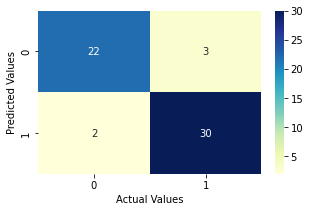

In [55]:
print(" Test Accuracy score : ",round(rfc.score(x_test,y_test)*100,2),"%")
print("Train Accuracy score : ",round(rfc.score(x_train,y_train)*100,2),"%")
clf_con = confusion_matrix(y_test,rfc_pred)
print("----------------------")
print("Classification Report")
print("----------------------")
print(classification_report(y_test,rfc_pred))
plt.figure(figsize=(5,3))
sns.heatmap(clf_con, annot=True,cmap="YlGnBu",fmt='g')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [48]:
auc = roc_auc_score(y_test,rfc_pred)
auc

0.9087500000000001

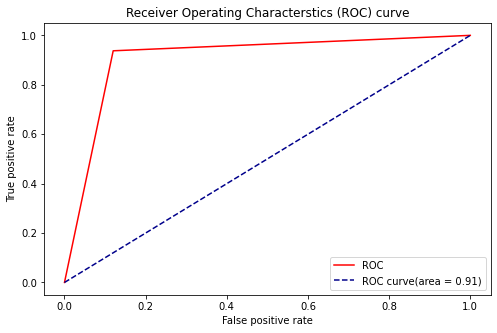

In [49]:
fpr, tpr, thresholds = roc_curve(y_test,rfc_pred)
plt.figure(figsize=(8,5))
plt.plot(fpr , tpr , color='red',label='ROC')
plt.plot([0,1],[0,1],color = 'darkblue',linestyle='--',label='ROC curve(area = %0.2f)'% auc)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver Operating Characterstics (ROC) curve')
plt.legend()
plt.show()

# Model Comparison

In [50]:
data = { 'Models' : ['Logistic Regression','Random Forest'],
         'Test Accuracy' : [round(lr.score(x_test,y_test)*100,2), round(rfc.score(x_test,y_test)*100,2)],
         'Train Accuracy': [round(lr.score(x_train,y_train)*100,2),round(rfc.score(x_train,y_train)*100,2)],
       }

df = pd.DataFrame(data)
df.sort_values(by='Test Accuracy',ascending=False)

,Models,Test Accuracy,Train Accuracy
1,Random Forest,91.23,85.84
0,Logistic Regression,85.96,84.07


<AxesSubplot:xlabel='Test Accuracy'>

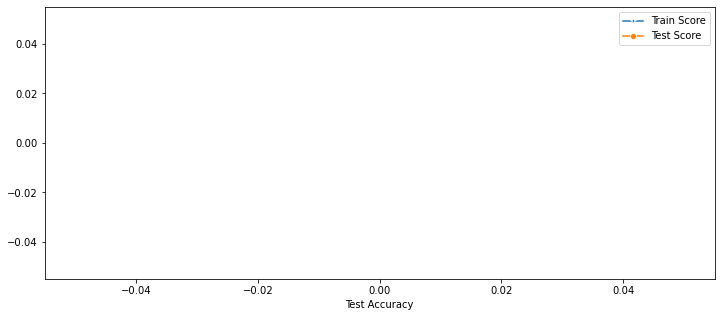

In [52]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Test Accuracy',marker='*',label='Train Score',data=df)
sns.lineplot(x='Train Accuracy',marker='o',label='Test Score',data=df)

In [ ]:
plt.figure(figsize = (5,6))
sns.barplot(x='Models', y='Test Accuracy',data=df)
plt.show()

## Data Testing

In [ ]:
data2.head(25)

In [ ]:
sample1 = [45,1,0,104,208,0,0,148,1,3.0,1,0,2]
if rfc.predict([sample1]) == 0:
    print('[SAFE] HEART DISEASE NOT DETECTED')
else:
    print(' [WARNING] HEART DISEASE DETECTED')


In [ ]:
sample2 = [45,1,0,104,208,0,0,148,1,3.0,1,0,2]
if lr.predict([sample2]) == 0:
    print('[SAFE] HEART DISEASE NOT DETECTED')
else:
    print(' [WARNING] HEART DISEASE DETECTED')